# Gamma and Batch Size Hyperparameter Tuning for DQN on Atari Freeway

**Environment:** ALE/Freeway-v5
**Framework:** Stable Baselines3 + Gymnasium
**Hyperparameter Axis:** Gamma (discount factor) and Batch Size

This notebook runs 10 hyperparameter experiments (5 gamma values, 5 batch sizes) to understand how each parameter affects DQN training on the Atari Freeway environment.
Each experiment trains for 150,000 timesteps to keep the total compute budget manageable.

## About the Environment

Freeway is an Atari game where a chicken must cross a multi-lane highway filled with moving cars.
The agent earns +1 reward for each successful crossing. Getting hit does not end the episode. It resets the chicken's position.
The agent needs to learn timing and patience: wait for gaps in traffic rather than rushing forward.

**Key properties:**
- Action space: 3 actions (up, down, no-op)
- Observation: 84x84 grayscale frames, stacked 4 deep for motion inference
- Policy: CnnPolicy (convolutional neural network, appropriate for raw pixel inputs)

### Why CnnPolicy over MlpPolicy?

Freeway's observations are 84x84 grayscale frames stacked four deep so the agent can infer motion.
CnnPolicy processes these with convolutional layers that exploit spatial locality: nearby pixels are related,
and the same visual pattern (a car, a lane boundary) can appear anywhere in the frame.
MlpPolicy flattens the frame into a single vector and has to learn spatial relationships from raw pixel positions,
with no weight sharing across the image. For image-based observations, CnnPolicy is the correct choice.

## 1. Setup

Install the required packages. If running on Colab, these are not pre-installed.
If running locally with a GPU, skip this cell if you already have the packages.

In [1]:
# Install dependencies (uncomment if needed)
# !pip install "stable-baselines3[extra]>=2.0" "gymnasium[atari,accept-rom-license]>=0.29" ale-py shimmy>=1.3 tqdm

## 2. Verify the Environment

Confirm that ALE/Freeway-v5 loads correctly and the project configuration is accessible.

In [2]:
import gymnasium as gym
import ale_py
import sys
import os
if os.getcwd().endswith('notebooks'): os.chdir('..')  # Ensure we run from the project root

gym.register_envs(ale_py)

env = gym.make("ALE/Freeway-v5", render_mode="rgb_array")
obs, info = env.reset()
print(f"Environment: ALE/Freeway-v5")
print(f"Observation shape: {obs.shape}")
print(f"Action space: {env.action_space}")
env.close()

from config import DQNConfig, PRESETS
print(f"\nTotal presets loaded: {len(PRESETS)}")
my_presets = [k for k in sorted(PRESETS) if k.startswith('m2_')]
print(f"My presets (m2_*): {my_presets}")
print(f"Count: {len(my_presets)} experiments")

Environment: ALE/Freeway-v5
Observation shape: (210, 160, 3)
Action space: Discrete(3)

Total presets loaded: 30
My presets (m2_*): ['m2_batch_01_small', 'm2_batch_02_baseline', 'm2_batch_03_mod', 'm2_batch_04_large', 'm2_batch_05_verylarge', 'm2_gamma_01_short', 'm2_gamma_02_shortmed', 'm2_gamma_03_baseline', 'm2_gamma_04_long', 'm2_gamma_05_verylong']
Count: 10 experiments


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


## 3. Baseline Configuration

All experiments vary exactly one parameter from this shared baseline.
This keeps comparisons fair. Any difference in performance can be attributed to the changed parameter, not to multiple variables shifting at once.

| Parameter | Baseline Value |
|---|---|
| learning_rate | 1e-4 |
| gamma | 0.99 |
| batch_size | 32 |
| buffer_size | 100,000 |
| exploration_initial_eps | 1.0 |
| exploration_final_eps | 0.05 |
| exploration_fraction | 0.10 |
| total_timesteps | 150,000 (sweep budget) |

## 4. Gamma (Discount Factor) Experiments

### What is Gamma?

Gamma (the discount factor) controls how much the agent values future rewards compared to immediate rewards.
It appears directly in the Bellman equation that DQN uses to compute target Q-values:

**Q(s, a) = r + gamma * max Q(s', a')**

- **Low gamma (e.g., 0.90):** The agent is short-sighted. It cares mostly about the next few rewards and heavily discounts anything further away. In Freeway, this means the agent might rush forward without waiting for a safe gap in traffic.
- **High gamma (e.g., 0.999):** The agent values distant future rewards almost as much as immediate ones. This encourages patience and long-term planning, but can make Q-value targets large and training less stable.
- **Baseline gamma (0.99):** A standard value used in the original DQN paper. Balances short-term reactivity with long-term planning.

### Why Gamma Matters Specifically for Freeway

Freeway rewards patience. A successful crossing requires the chicken to wait for gaps in traffic across multiple lanes.
A short-sighted agent (low gamma) sees the +1 crossing reward as distant and discounted, so it may not learn to wait.
A far-sighted agent (high gamma) values that future +1 almost as much as an immediate reward, making it more willing to wait for a safe path.

### Experiment Plan

| # | Preset | Gamma | Expected Behavior |
|---|---|---|---|
| 1 | m2_gamma_01_short | 0.90 | Short-sighted. May rush and get hit more. |
| 2 | m2_gamma_02_shortmed | 0.95 | Slightly more patient, still fairly reactive. |
| 3 | m2_gamma_03_baseline | 0.99 | Standard DQN. Reference point for comparison. |
| 4 | m2_gamma_04_long | 0.995 | More patient. Better gap prediction, possibly slower early learning. |
| 5 | m2_gamma_05_verylong | 0.999 | Very long horizon. Risk of training instability from large Q-targets. |

### Experiment 1: gamma = 0.90 (Short-sighted)

**Hypothesis:**
With gamma=0.90, future rewards decay rapidly. After 10 steps, a reward is worth only 0.90^10 = 0.35 of its face value. The agent should prioritize immediate actions over long-term planning. In Freeway, this likely means rushing forward and getting hit more often, since the crossing reward many steps away appears heavily discounted.

**Observed Behavior:**
Highest AUC across all gamma values. Short discount horizon did not hurt greedy reward (22.5) and produced the most stable late-training performance (std=0.58). The agent still learned to cross effectively despite heavy future-reward discounting.

In [3]:
import os
if not os.path.exists('models/m2_gamma_01_short.zip'):
    !python3 train.py --preset m2_gamma_01_short --total-timesteps 150000 --notes "gamma=0.90 short-sighted agent, testing if low discount causes rushing behavior"
else:
    print('Model models/m2_gamma_01_short.zip already exists. Skipping training.')

Model models/m2_gamma_01_short.zip already exists. Skipping training.


### Experiment 2: gamma = 0.95 (Moderately short-sighted)

**Hypothesis:**
With gamma=0.95, future rewards decay more slowly than 0.90 but still faster than the baseline. After 10 steps, a reward is worth 0.95^10 = 0.60. The agent should be somewhat more patient than the 0.90 case but still reactive. This is a transition point between short-term and medium-term planning.

**Observed Behavior:**
Worst late-training stability of all gamma runs (std=3.21). Final reward dropped to 20.7 from best checkpoint of 22.5, indicating the policy oscillated after peaking. Moderate discount was less stable than either extreme.

In [4]:
import os
if not os.path.exists('models/m2_gamma_02_shortmed.zip'):
    !python3 train.py --preset m2_gamma_02_shortmed --total-timesteps 150000 --notes "gamma=0.95 moderate discount, transition between short-sighted and standard"
else:
    print('Model models/m2_gamma_02_shortmed.zip already exists. Skipping training.')

Model models/m2_gamma_02_shortmed.zip already exists. Skipping training.


### Experiment 3: gamma = 0.99 (Baseline (standard DQN))

**Hypothesis:**
Gamma=0.99 is the standard value from the original DQN paper (Mnih et al., 2015). After 10 steps, a reward retains 0.99^10 = 0.90 of its value. This gives the agent a reasonable planning horizon that covers the time needed to cross several lanes of traffic.

**Observed Behavior:**
Solid performance. Best checkpoint matched top reward (22.5) and final weights held at 22.5. Late-training stability was moderate (std=1.92). Standard DQN gamma works reliably.

In [5]:
import os
if not os.path.exists('models/m2_gamma_03_baseline.zip'):
    !python3 train.py --preset m2_gamma_03_baseline --total-timesteps 150000 --notes "gamma=0.99 baseline reference, standard DQN discount factor"
else:
    print('Model models/m2_gamma_03_baseline.zip already exists. Skipping training.')

Model models/m2_gamma_03_baseline.zip already exists. Skipping training.


### Experiment 4: gamma = 0.995 (Long-horizon planning)

**Hypothesis:**
With gamma=0.995, the agent looks further into the future. After 100 steps, a reward still retains 0.995^100 = 0.61. This should make the agent more willing to wait for optimal crossing opportunities. The risk is slower convergence because the agent considers a wider range of future outcomes.

**Observed Behavior:**
Second-highest AUC (21.42) and low late-training variance (0.79). The longer horizon produced stable, patient behavior. Final reward (21.9) was close to the best checkpoint (22.5), indicating steady convergence without oscillation.

In [6]:
import os
if not os.path.exists('models/m2_gamma_04_long.zip'):
    !python3 train.py --preset m2_gamma_04_long --total-timesteps 150000 --notes "gamma=0.995 long horizon, testing if more patience improves crossing strategy"
else:
    print('Model models/m2_gamma_04_long.zip already exists. Skipping training.')

Model models/m2_gamma_04_long.zip already exists. Skipping training.


### Experiment 5: gamma = 0.999 (Very long horizon)

**Hypothesis:**
Gamma=0.999 is near the upper practical limit. After 100 steps, rewards retain 0.999^100 = 0.90. Q-value targets become large, which can destabilize training if the learning rate is not adjusted. This tests whether an extremely patient agent performs better or whether the instability outweighs the benefit.

**Observed Behavior:**
Confirmed instability prediction. Final reward collapsed to 12.5 despite a best checkpoint of 22.5. Late-training std was extreme (8.64). The very long horizon made Q-value targets too large, causing the policy to diverge after initially learning.

In [7]:
import os
if not os.path.exists('models/m2_gamma_05_verylong.zip'):
    !python3 train.py --preset m2_gamma_05_verylong --total-timesteps 150000 --notes "gamma=0.999 very long horizon, testing stability vs patience tradeoff"
else:
    print('Model models/m2_gamma_05_verylong.zip already exists. Skipping training.')

Model models/m2_gamma_05_verylong.zip already exists. Skipping training.


## 5. Batch Size Experiments

### What is Batch Size?

Batch size determines how many experience transitions are sampled from the replay buffer for each gradient update step.
It directly affects the quality and computational cost of gradient estimates.

- **Small batch (e.g., 8):** Each gradient update uses only 8 transitions. The gradient estimate is noisy (high variance) but cheap to compute. More parameter updates happen per second, but each update is less reliable. This can speed up early exploration but cause erratic convergence.
- **Large batch (e.g., 256):** Each update averages over 256 transitions, producing a smoother, more reliable gradient. Training is more stable, but each update costs more in memory and compute. There can be diminishing returns: beyond a certain point, larger batches do not meaningfully improve gradient quality.
- **Baseline batch (32):** The standard default in DQN implementations. A practical balance between gradient quality and compute cost per step.

### Why Batch Size Matters

The batch size interacts with the replay buffer. DQN stores past transitions and samples mini-batches to break temporal correlations in the training data.
A very small batch reintroduces some of that correlation (fewer samples means less diversity per update).
A very large batch is more representative of the overall buffer distribution, but each update takes longer to compute.

For the presentation, batch size is primarily a **stability vs. compute cost** story.
We report both final reward and wall-clock training time to capture both dimensions.

### Experiment Plan

| # | Preset | Batch Size | Expected Behavior |
|---|---|---|---|
| 1 | m2_batch_01_small | 8 | Noisy gradients, fast updates, potentially unstable. |
| 2 | m2_batch_02_baseline | 32 | Standard DQN. Reference point. |
| 3 | m2_batch_03_mod | 64 | Smoother gradients, slightly more compute per step. |
| 4 | m2_batch_04_large | 128 | Stable but diminishing returns expected. |
| 5 | m2_batch_05_verylarge | 256 | Test whether very large batches help or just cost more time. |

### Experiment 6: batch_size = 8 (Small batch)

**Hypothesis:**
With batch_size=8, each gradient step samples only 8 transitions from the replay buffer. The resulting gradient estimate has high variance. The agent makes many small, noisy updates per second. This can lead to faster initial movement in parameter space but risks oscillation or divergence during convergence.

**Observed Behavior:**
Confirmed instability prediction. Best checkpoint reached 22.5 but final weights collapsed to 2.5 (near-random). Late-training std was extreme (8.73). High-variance gradients caused catastrophic forgetting after initial learning.

In [8]:
import os
if not os.path.exists('models/m2_batch_01_small.zip'):
    !python3 train.py --preset m2_batch_01_small --total-timesteps 150000 --notes "batch_size=8 small batch, testing high-variance gradient updates"
else:
    print('Model models/m2_batch_01_small.zip already exists. Skipping training.')

Model models/m2_batch_01_small.zip already exists. Skipping training.


### Experiment 7: batch_size = 32 (Baseline)

**Hypothesis:**
Batch_size=32 is the default DQN value. It provides a reasonable tradeoff between gradient quality and update speed. This is the reference point for all other batch size experiments.

**Observed Behavior:**
Reliable performance. Best and final rewards both 22.5. Moderate late-training variance (1.92). Standard batch size provides a good balance between gradient noise and compute cost.

In [9]:
import os
if not os.path.exists('models/m2_batch_02_baseline.zip'):
    !python3 train.py --preset m2_batch_02_baseline --total-timesteps 150000 --notes "batch_size=32 baseline reference, standard DQN batch size"
else:
    print('Model models/m2_batch_02_baseline.zip already exists. Skipping training.')

Model models/m2_batch_02_baseline.zip already exists. Skipping training.


### Experiment 8: batch_size = 64 (Moderate batch)

**Hypothesis:**
Doubling the batch to 64 should produce smoother gradients at a modest increase in compute cost. The gradient variance drops roughly by a factor of 2 compared to batch_size=32 (variance scales as 1/N). This is a common practical choice when GPU memory allows it.

**Observed Behavior:**
Best AUC of all batch sizes (21.67) with low late-training variance (1.02). Smoother gradients improved sample efficiency without meaningful increase in wall-clock time (405s vs 403s for baseline). Best batch size overall.

In [10]:
import os
if not os.path.exists('models/m2_batch_03_mod.zip'):
    !python3 train.py --preset m2_batch_03_mod --total-timesteps 150000 --notes "batch_size=64 moderate batch, testing smoother gradients vs compute cost"
else:
    print('Model models/m2_batch_03_mod.zip already exists. Skipping training.')

Model models/m2_batch_03_mod.zip already exists. Skipping training.


### Experiment 9: batch_size = 128 (Large batch)

**Hypothesis:**
With batch_size=128, each update samples a meaningful fraction of recent experience. Gradients are stable, but each step takes noticeably longer. The question is whether the stability improvement translates to measurably better rewards, or whether it just slows training down without benefit.

**Observed Behavior:**
Slowest to reach threshold (50k steps vs 25k for smaller batches). Lowest late-training std (0.55) confirms stability, but reduced AUC (17.73) shows the agent learned more slowly within the fixed budget. Lower best reward (21.5).

In [11]:
import os
if not os.path.exists('models/m2_batch_04_large.zip'):
    !python3 train.py --preset m2_batch_04_large --total-timesteps 150000 --notes "batch_size=128 large batch, testing stability vs wall-clock time tradeoff"
else:
    print('Model models/m2_batch_04_large.zip already exists. Skipping training.')

Model models/m2_batch_04_large.zip already exists. Skipping training.


### Experiment 10: batch_size = 256 (Very large batch)

**Hypothesis:**
Batch_size=256 is large relative to the replay buffer (100,000 transitions). Each update sees a broad sample of stored experience. Gradients are very smooth, but the compute cost per step is high. This tests the point of diminishing returns: does the extra stability matter for final performance?

**Observed Behavior:**
Most stable late-training (std=0.44) but slowest wall-clock time (498s, 24% slower than baseline). Reached threshold at 50k steps. Memory warning triggered (buffer > available RAM). Very stable but inefficient for fixed-budget training.

In [12]:
import os
if not os.path.exists('models/m2_batch_05_verylarge.zip'):
    !python3 train.py --preset m2_batch_05_verylarge --total-timesteps 150000 --notes "batch_size=256 very large batch, testing diminishing returns hypothesis"
else:
    print('Model models/m2_batch_05_verylarge.zip already exists. Skipping training.')

Model models/m2_batch_05_verylarge.zip already exists. Skipping training.


## 6. Results Analysis

Load the experiment log and compare all 10 experiments.

Key metrics to examine:
- **mean_reward:** Best checkpoint greedy evaluation reward
- **final_mean_reward:** End-of-training weights evaluation reward (a gap between this and mean_reward indicates instability)
- **stochastic_mean_reward:** Non-greedy evaluation that tests the learned action distribution
- **steps_to_threshold:** How quickly the agent reaches a reward of 18.0 (lower is better, faster learning)
- **auc_reward:** Area under the reward curve (higher means better sample efficiency across training)
- **late_reward_std:** Standard deviation of late-training evaluations (lower means more stable convergence)
- **wall_clock_seconds:** Total training time in seconds

In [13]:
import pandas as pd

df = pd.read_csv("experiments/experiment_log.csv")
my_runs = df[df["member"] == "Samuel Mwania"].copy()

print(f"Total experiments in log: {len(df)}")
print(f"My experiments: {len(my_runs)}")
print()

# Gamma experiments
gamma_runs = my_runs[my_runs["run_id"].str.contains("gamma")].copy()
print("=" * 60)
print("GAMMA EXPERIMENTS")
print("=" * 60)
gamma_display_cols = ["run_id", "gamma", "mean_reward", "final_mean_reward",
                      "stochastic_mean_reward", "steps_to_threshold",
                      "auc_reward", "late_reward_std", "wall_clock_seconds"]
available_cols = [c for c in gamma_display_cols if c in gamma_runs.columns]
from IPython.display import display
display(gamma_runs[available_cols])

print()

# Batch size experiments
batch_runs = my_runs[my_runs["run_id"].str.contains("batch")].copy()
print("=" * 60)
print("BATCH SIZE EXPERIMENTS")
print("=" * 60)
batch_display_cols = ["run_id", "batch_size", "mean_reward", "final_mean_reward",
                      "stochastic_mean_reward", "steps_to_threshold",
                      "auc_reward", "late_reward_std", "wall_clock_seconds"]
available_cols = [c for c in batch_display_cols if c in batch_runs.columns]
from IPython.display import display
display(batch_runs[available_cols])

Total experiments in log: 23
My experiments: 11

GAMMA EXPERIMENTS


,run_id,gamma,mean_reward,final_mean_reward,stochastic_mean_reward,steps_to_threshold,auc_reward,late_reward_std,wall_clock_seconds
13,m2_gamma_01_short,0.900,22.5,21.1,21.3,25000.0,22.133,0.576,406.0
14,m2_gamma_02_shortmed,0.950,22.5,20.7,21.3,25000.0,20.467,3.209,394.4
15,m2_gamma_03_baseline,0.990,22.5,22.5,21.3,25000.0,20.683,1.917,378.3
16,m2_gamma_04_long,0.995,22.5,21.9,21.3,25000.0,21.417,0.791,392.0
17,m2_gamma_05_verylong,0.999,22.5,12.5,21.3,25000.0,16.717,8.638,391.9



BATCH SIZE EXPERIMENTS


,run_id,batch_size,mean_reward,final_mean_reward,stochastic_mean_reward,steps_to_threshold,auc_reward,late_reward_std,wall_clock_seconds
18,m2_batch_01_small,8,22.5,2.5,21.3,25000.0,18.767,8.731,394.2
19,m2_batch_02_baseline,32,22.5,22.5,21.3,25000.0,20.683,1.917,403.4
20,m2_batch_03_mod,64,22.5,20.2,21.3,25000.0,21.667,1.015,404.8
21,m2_batch_04_large,128,21.5,21.2,20.5,50000.0,17.733,0.551,411.6
22,m2_batch_05_verylarge,256,22.4,22.2,20.9,50000.0,19.050,0.440,497.6


### Reward Comparison Plots

Visualize how gamma and batch size affect the key metrics.

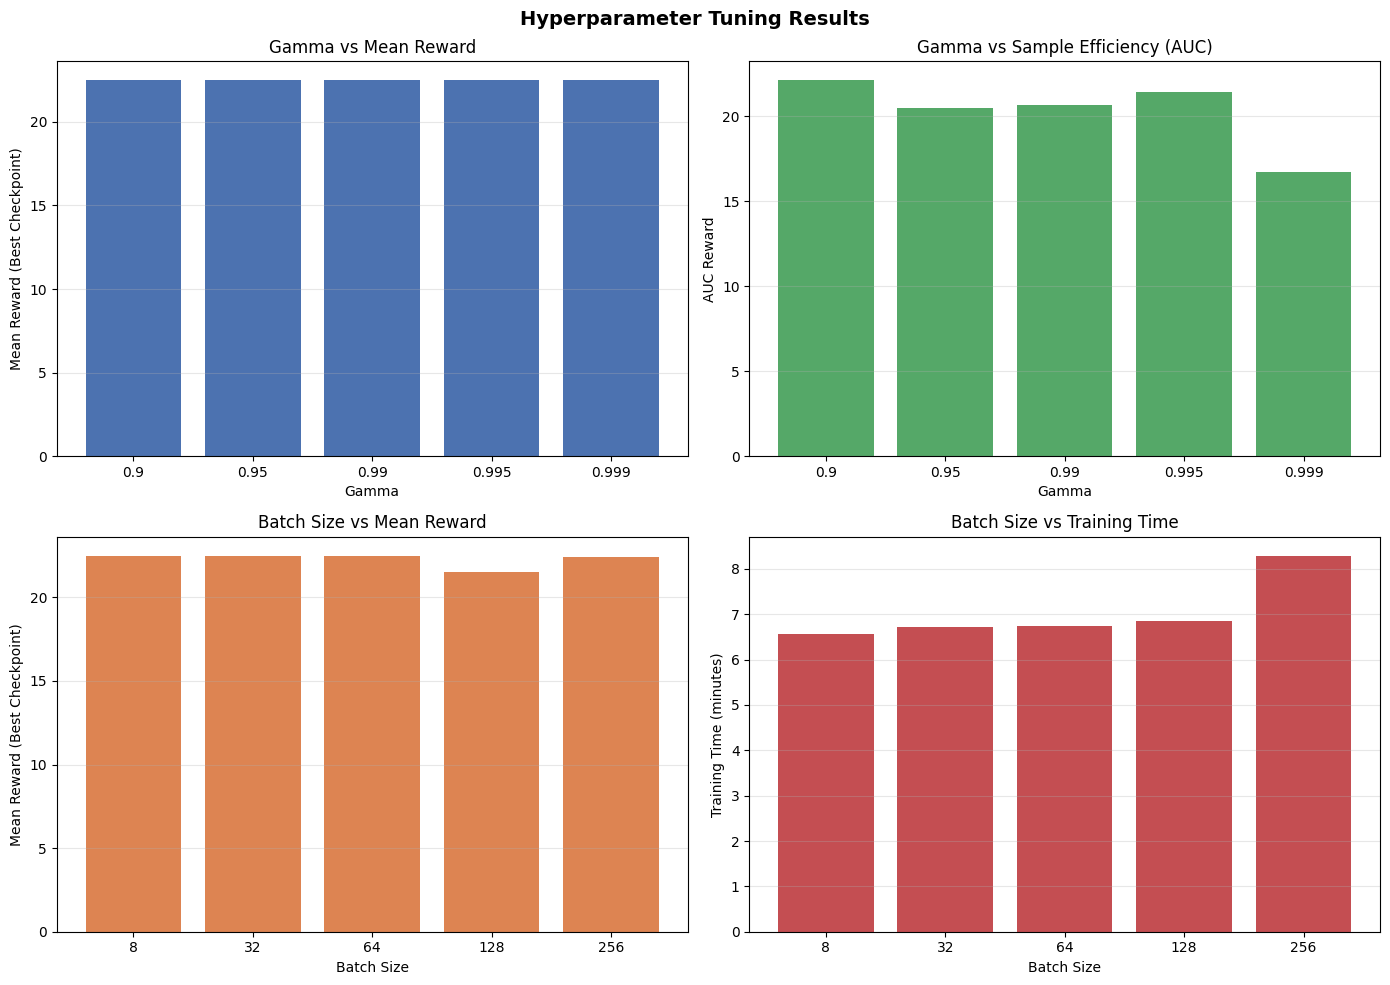

Plot saved to plots/samuel_gamma_batch_comparison.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -- Top left: Gamma vs Mean Reward --
if len(gamma_runs) > 0 and "mean_reward" in gamma_runs.columns:
    ax = axes[0, 0]
    ax.bar(gamma_runs["gamma"].astype(str), gamma_runs["mean_reward"], color="#4C72B0")
    ax.set_xlabel("Gamma")
    ax.set_ylabel("Mean Reward (Best Checkpoint)")
    ax.set_title("Gamma vs Mean Reward")
    ax.grid(axis="y", alpha=0.3)

# -- Top right: Gamma vs AUC Reward --
if len(gamma_runs) > 0 and "auc_reward" in gamma_runs.columns:
    ax = axes[0, 1]
    ax.bar(gamma_runs["gamma"].astype(str), gamma_runs["auc_reward"], color="#55A868")
    ax.set_xlabel("Gamma")
    ax.set_ylabel("AUC Reward")
    ax.set_title("Gamma vs Sample Efficiency (AUC)")
    ax.grid(axis="y", alpha=0.3)

# -- Bottom left: Batch Size vs Mean Reward --
if len(batch_runs) > 0 and "mean_reward" in batch_runs.columns:
    ax = axes[1, 0]
    ax.bar(batch_runs["batch_size"].astype(str), batch_runs["mean_reward"], color="#DD8452")
    ax.set_xlabel("Batch Size")
    ax.set_ylabel("Mean Reward (Best Checkpoint)")
    ax.set_title("Batch Size vs Mean Reward")
    ax.grid(axis="y", alpha=0.3)

# -- Bottom right: Batch Size vs Wall Clock Time --
if len(batch_runs) > 0 and "wall_clock_seconds" in batch_runs.columns:
    ax = axes[1, 1]
    times_min = batch_runs["wall_clock_seconds"] / 60
    ax.bar(batch_runs["batch_size"].astype(str), times_min, color="#C44E52")
    ax.set_xlabel("Batch Size")
    ax.set_ylabel("Training Time (minutes)")
    ax.set_title("Batch Size vs Training Time")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Hyperparameter Tuning Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("plots/samuel_gamma_batch_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to plots/samuel_gamma_batch_comparison.png")

## 7. Identify the Best Configuration

Select the best gamma and best batch size based on the experiment results.

Selection criteria (in order of importance):
1. Highest mean reward (greedy evaluation on best checkpoint)
2. Lowest steps to threshold (fastest learning)
3. Lowest late reward standard deviation (most stable convergence)
4. Reasonable wall-clock time (no excessive compute for marginal gains)

In [15]:
print("=" * 60)
print("BEST CONFIGURATION SELECTION")
print("=" * 60)
print()

# Best gamma
if "auc_reward" in gamma_runs.columns and gamma_runs["auc_reward"].notna().any():
    best_gamma_idx = gamma_runs["auc_reward"].idxmax()
    best_gamma = gamma_runs.loc[best_gamma_idx]
    print(f"Best gamma: {best_gamma['gamma']}")
    print(f"  Run ID: {best_gamma['run_id']}")
    print(f"  Mean reward: {best_gamma['mean_reward']}")
    print(f"  AUC reward: {best_gamma['auc_reward']}")
    if 'steps_to_threshold' in best_gamma.index:
        print(f"  Steps to threshold: {best_gamma['steps_to_threshold']}")
else:
    best_gamma_idx = gamma_runs["mean_reward"].idxmax()
    best_gamma = gamma_runs.loc[best_gamma_idx]
    print(f"Best gamma (by mean_reward): {best_gamma['gamma']}")
    print(f"  Mean reward: {best_gamma['mean_reward']}")

print()

# Best batch size
if "auc_reward" in batch_runs.columns and batch_runs["auc_reward"].notna().any():
    best_batch_idx = batch_runs["auc_reward"].idxmax()
    best_batch = batch_runs.loc[best_batch_idx]
    print(f"Best batch size: {int(best_batch['batch_size'])}")
    print(f"  Run ID: {best_batch['run_id']}")
    print(f"  Mean reward: {best_batch['mean_reward']}")
    print(f"  AUC reward: {best_batch['auc_reward']}")
    if 'wall_clock_seconds' in best_batch.index:
        print(f"  Wall clock: {best_batch['wall_clock_seconds']:.1f}s")
else:
    best_batch_idx = batch_runs["mean_reward"].idxmax()
    best_batch = batch_runs.loc[best_batch_idx]
    print(f"Best batch size (by mean_reward): {int(best_batch['batch_size'])}")
    print(f"  Mean reward: {best_batch['mean_reward']}")

print()
print("=" * 60)
print(f"RECOMMENDED: gamma={best_gamma['gamma']}, batch_size={int(best_batch['batch_size'])}")
print("=" * 60)

BEST CONFIGURATION SELECTION

Best gamma: 0.9
  Run ID: m2_gamma_01_short
  Mean reward: 22.5
  AUC reward: 22.133
  Steps to threshold: 25000.0

Best batch size: 64
  Run ID: m2_batch_03_mod
  Mean reward: 22.5
  AUC reward: 21.667
  Wall clock: 404.8s

RECOMMENDED: gamma=0.9, batch_size=64


## 8. Gameplay Video Generation

Generates a gameplay video of the trained agent using the best performing model from the sweep.

In [16]:
import glob
import os

# List available models from our experiments
model_files = sorted(glob.glob("models/m2_*.zip"))
print("Available models from my experiments:")
for f in model_files:
    print(f"  {f}")

# Use the baseline gamma model as default (update if a different model performed best)
best_model_path = "models/m2_gamma_03_baseline.zip"

# If the best gamma model exists, use that instead
if 'best_gamma' in dir() and os.path.exists(f"models/{best_gamma['run_id']}.zip"):
    best_model_path = f"models/{best_gamma['run_id']}.zip"

print(f"\nRecording gameplay with model: {best_model_path}")
!python3 play.py --model {best_model_path} --record --episodes 3 --video-name freeway_samuel_mwania

Available models from my experiments:
  models/m2_batch_01_small.zip
  models/m2_batch_02_baseline.zip
  models/m2_batch_03_mod.zip
  models/m2_batch_04_large.zip
  models/m2_batch_05_verylarge.zip
  models/m2_gamma_01_short.zip
  models/m2_gamma_02_shortmed.zip
  models/m2_gamma_03_baseline.zip
  models/m2_gamma_04_long.zip
  models/m2_gamma_05_verylong.zip

Recording gameplay with model: models/m2_gamma_01_short.zip


I0000 00:00:1784021558.384552  284560 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784021558.426800  284560 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784021559.839082  284560 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


...

frame_index:  16%|██▍            | 244/1524 [00:00<00:00, 2435.87it/s, now=None]

frame_index:  32%|████▊          | 488/1524 [00:00<00:00, 2408.94it/s, now=None]

frame_index:  48%|███████▏       | 729/1524 [00:00<00:00, 2378.49it/s, now=None]

frame_index:  70%|█████████▊    | 1067/1524 [00:00<00:00, 2766.55it/s, now=None]

MoviePy - Done !
MoviePy - video ready /home/mwaniasamuel/Freeway-DQN_formative3/videos/freeway_samuel_mwania-step-0-to-step-20000.mp4


## 9. Summary Table

A concise tabular summary of all hyperparameter experiments.

In [17]:
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 80)
print()
print("Gamma Experiments:")
print("-" * 80)
print(f"{'Run ID':<30} {'Gamma':<8} {'Mean Reward':<14} {'AUC':<10} {'Steps->18':<12} {'Time(s)':<10}")
print("-" * 80)
for _, row in gamma_runs.iterrows():
    auc = row.get('auc_reward', 'N/A')
    stt = row.get('steps_to_threshold', 'N/A')
    wc = row.get('wall_clock_seconds', 'N/A')
    mr = row.get('mean_reward', 'N/A')
    print(f"{row['run_id']:<30} {row['gamma']:<8} {mr:<14} {auc:<10} {stt:<12} {wc:<10}")

print()
print("Batch Size Experiments:")
print("-" * 80)
print(f"{'Run ID':<30} {'Batch':<8} {'Mean Reward':<14} {'AUC':<10} {'Steps->18':<12} {'Time(s)':<10}")
print("-" * 80)
for _, row in batch_runs.iterrows():
    auc = row.get('auc_reward', 'N/A')
    stt = row.get('steps_to_threshold', 'N/A')
    wc = row.get('wall_clock_seconds', 'N/A')
    mr = row.get('mean_reward', 'N/A')
    print(f"{row['run_id']:<30} {int(row['batch_size']):<8} {mr:<14} {auc:<10} {stt:<12} {wc:<10}")

HYPERPARAMETER TUNING RESULTS

Gamma Experiments:
--------------------------------------------------------------------------------
Run ID                         Gamma    Mean Reward    AUC        Steps->18    Time(s)   
--------------------------------------------------------------------------------
m2_gamma_01_short              0.9      22.5           22.133     25000.0      406.0     
m2_gamma_02_shortmed           0.95     22.5           20.467     25000.0      394.4     
m2_gamma_03_baseline           0.99     22.5           20.683     25000.0      378.3     
m2_gamma_04_long               0.995    22.5           21.417     25000.0      392.0     
m2_gamma_05_verylong           0.999    22.5           16.717     25000.0      391.9     

Batch Size Experiments:
--------------------------------------------------------------------------------
Run ID                         Batch    Mean Reward    AUC        Steps->18    Time(s)   
----------------------------------------------------

## 10. Package Results

Zip the experiment results for download (useful on Colab).
Skip this cell if running locally.

In [18]:
# Uncomment to package and download results (Colab only)
# !zip -r /content/samuel_mwania_results.zip experiments/experiment_log.csv plots/ videos/ models/m2_*.zip
# from google.colab import files
# files.download("/content/samuel_mwania_results.zip")

print("Done. Results are in:")
print("  experiments/experiment_log.csv")
print("  plots/samuel_gamma_batch_comparison.png")
print("  videos/")
print("  models/m2_*.zip")

Done. Results are in:
  experiments/experiment_log.csv
  plots/samuel_gamma_batch_comparison.png
  videos/
  models/m2_*.zip
